# **EDA Placement Outcomes**

Nama    : Leonardus Hasan

NIM     : 2802553480

Kelas   : LD09

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, root_mean_squared_error

In [224]:
df = pd.read_csv("D://University//Semester 4//Model Deployment//UTS//Dataset//B.csv")
df.head()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

In [226]:
df.isna().sum()

student_id                    0
gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score              0
internship_count              0
live_projects                 0
work_experience_months        0
certifications                0
attendance_percentage         0
backlogs                      0
extracurricular_activities    0
placement_status              0
salary_package_lpa            0
dtype: int64

In [227]:
df.duplicated().sum()

np.int64(0)

Tidak ditemukan adanya data yang duplikat dan NULL values. Maka dari itu, dapat dikatakan bahwa data ini bersih.

In [228]:
df.describe()

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,72.425800,71.910800,71.845200,7.678326,69.197800,69.651000,69.839600,1.987800,2.491800,11.982000,2.481000,79.433400,2.518400,0.173200,1.59589
std,1443.520003,13.199642,12.842781,10.013196,1.237084,17.325528,17.179704,17.170732,1.410975,1.704967,7.258114,1.719485,11.638585,1.721004,0.378458,3.77582
min,1.000000,50.000000,50.000000,55.000000,5.500000,40.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.00000
25%,1250.750000,61.000000,61.000000,63.000000,6.617500,54.000000,55.000000,55.000000,1.000000,1.000000,6.000000,1.000000,69.000000,1.000000,0.000000,0.00000
50%,2500.500000,72.000000,72.000000,72.000000,7.700000,69.000000,70.000000,69.000000,2.000000,3.000000,12.000000,2.000000,80.000000,3.000000,0.000000,0.00000
75%,3750.250000,84.000000,83.000000,80.000000,8.750000,84.000000,84.000000,85.000000,3.000000,4.000000,18.000000,4.000000,89.000000,4.000000,0.000000,0.00000
max,5000.000000,95.000000,94.000000,89.000000,9.800000,99.000000,99.000000,99.000000,4.000000,5.000000,24.000000,5.000000,99.000000,5.000000,1.000000,14.99000


In [229]:
cat_col = df.select_dtypes(include=object)
for i in cat_col:
    print(df[i].value_counts())
    print("\n")

gender
Male      2504
Female    2496
Name: count, dtype: int64


extracurricular_activities
No     2553
Yes    2447
Name: count, dtype: int64




Berdasarkan deskripsi dari prediktor numerikal dan kategorikal, tidak ditemukan adanya keanehan/nilai menyimpang dari yang seharusnya. Namun, untuk gender dan extracurricular_activies perlu dilakukan feature_engineering supaya dapat digunakan dalam pemodelan.

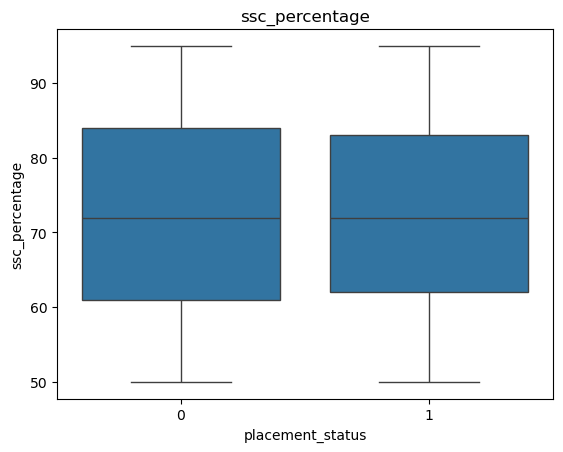

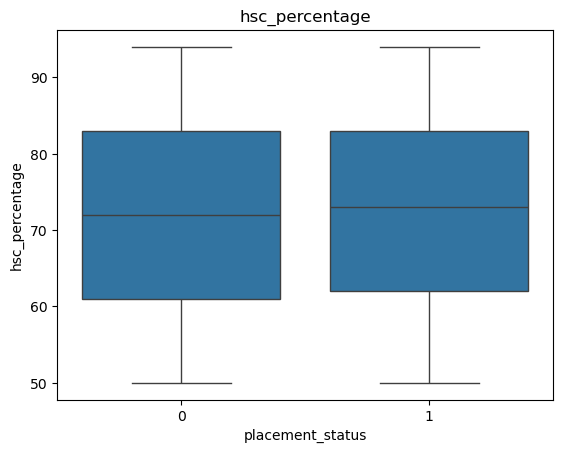

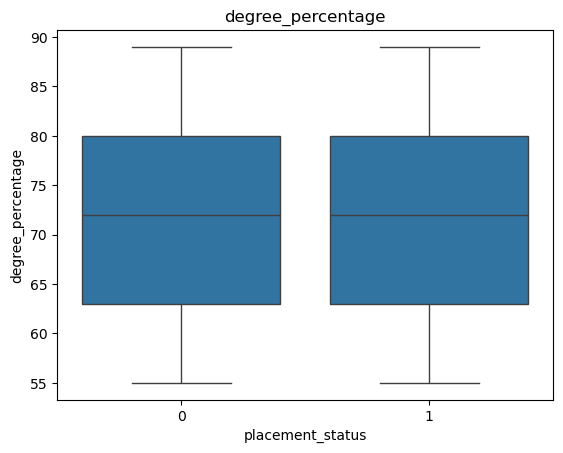

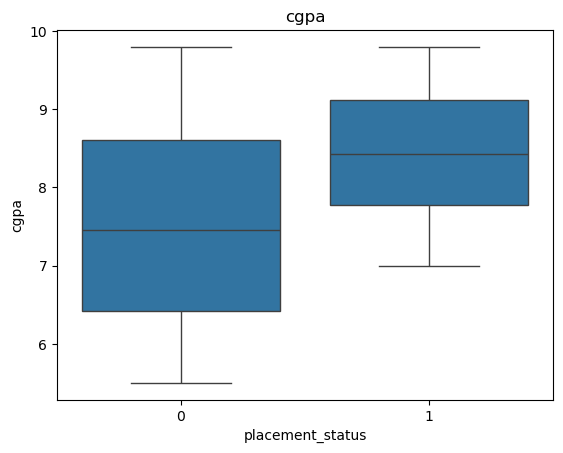

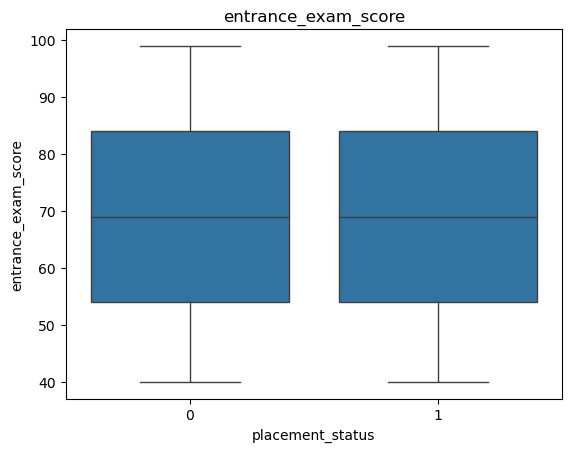

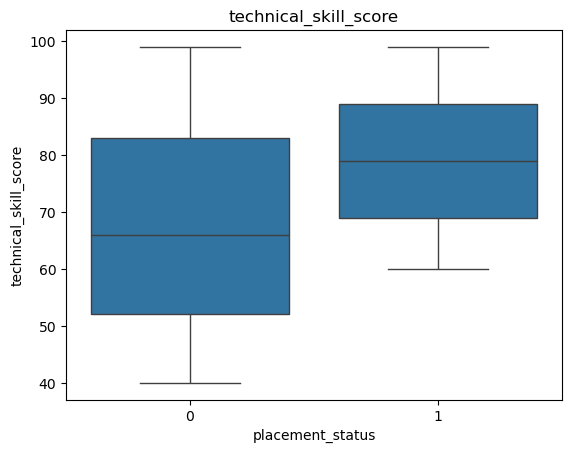

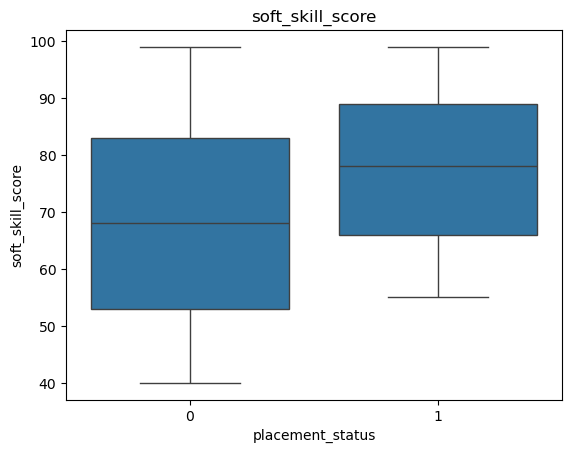

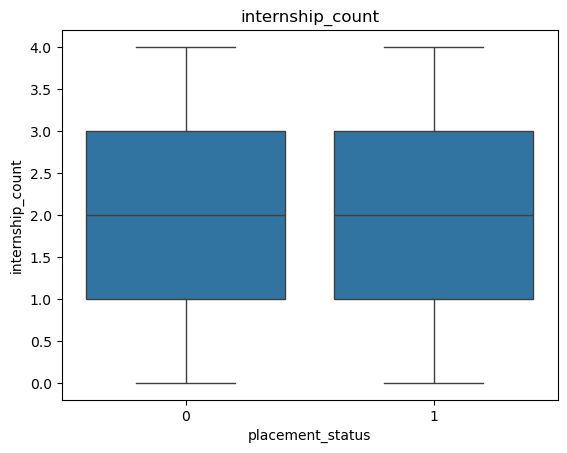

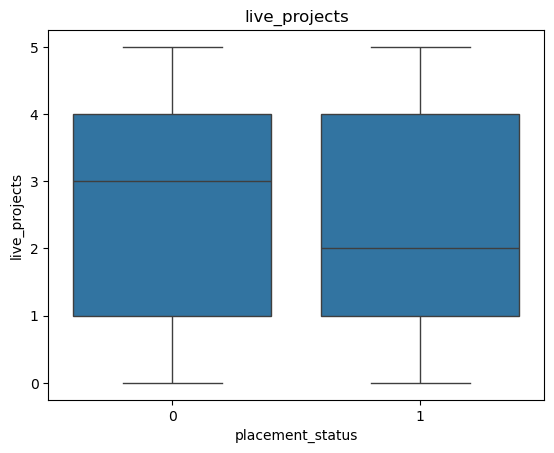

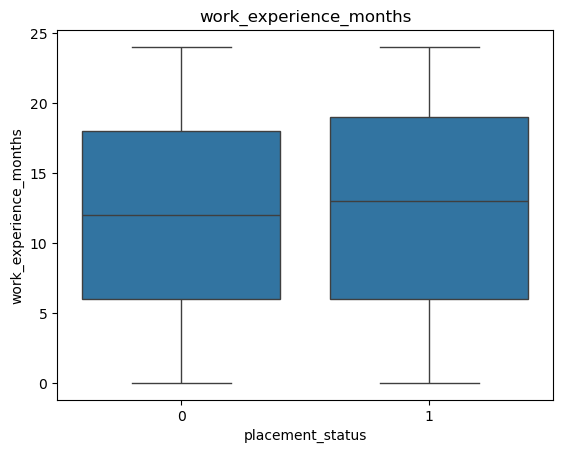

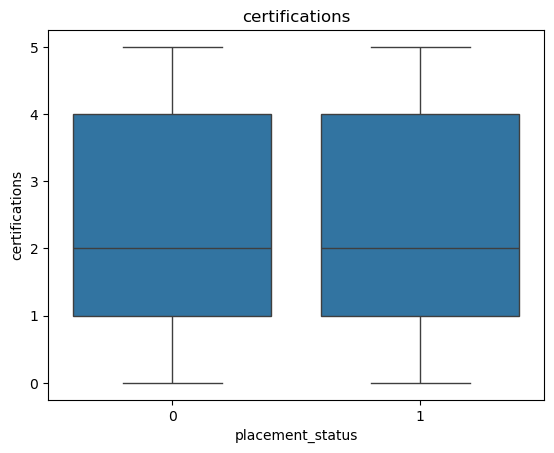

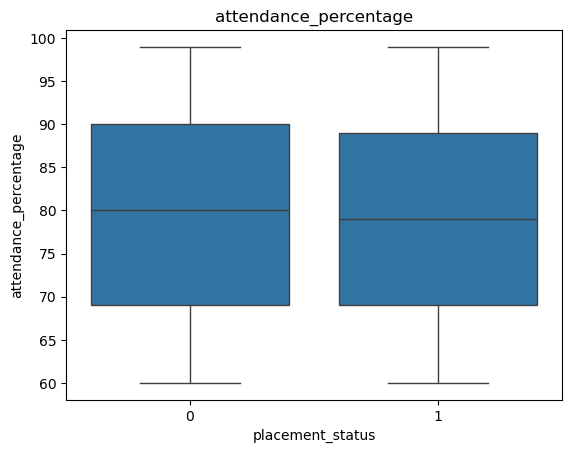

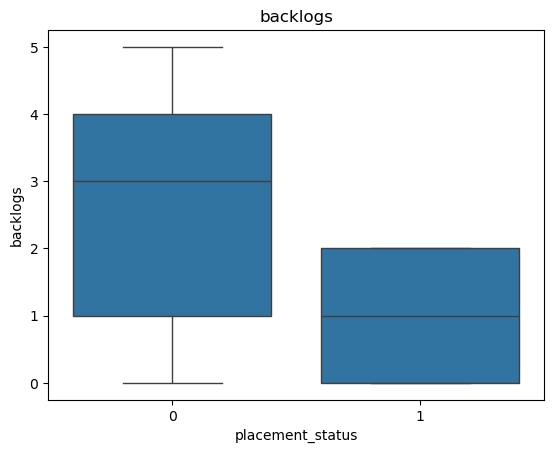

In [ ]:
num_col = df.select_dtypes(exclude=['object']).columns
num_col = num_col.drop(['student_id','placement_status', 'salary_package_lpa'], errors='ignore')
for i in num_col:
    plt.figure()
    sns.boxplot(x='placement_status', y=i, data=df)
    plt.title(i)
    plt.show()

**Feature Engineering**

In [ ]:
df['avg_skill_score'] = (df['technical_skill_score'] + df['soft_skill_score'])/2
df['skill_academic_score'] = df['avg_skill_score'] * df['cgpa']
df['skill_gap'] = df['technical_skill_score'] - df['soft_skill_score']
df['engagement_score'] = df['attendance_percentage'] * df['avg_skill_score']
num_col = list(num_col)
num_col = num_col + ['avg_skill_score', 'skill_academic_score','skill_gap', 'engagement_score']

<Axes: >

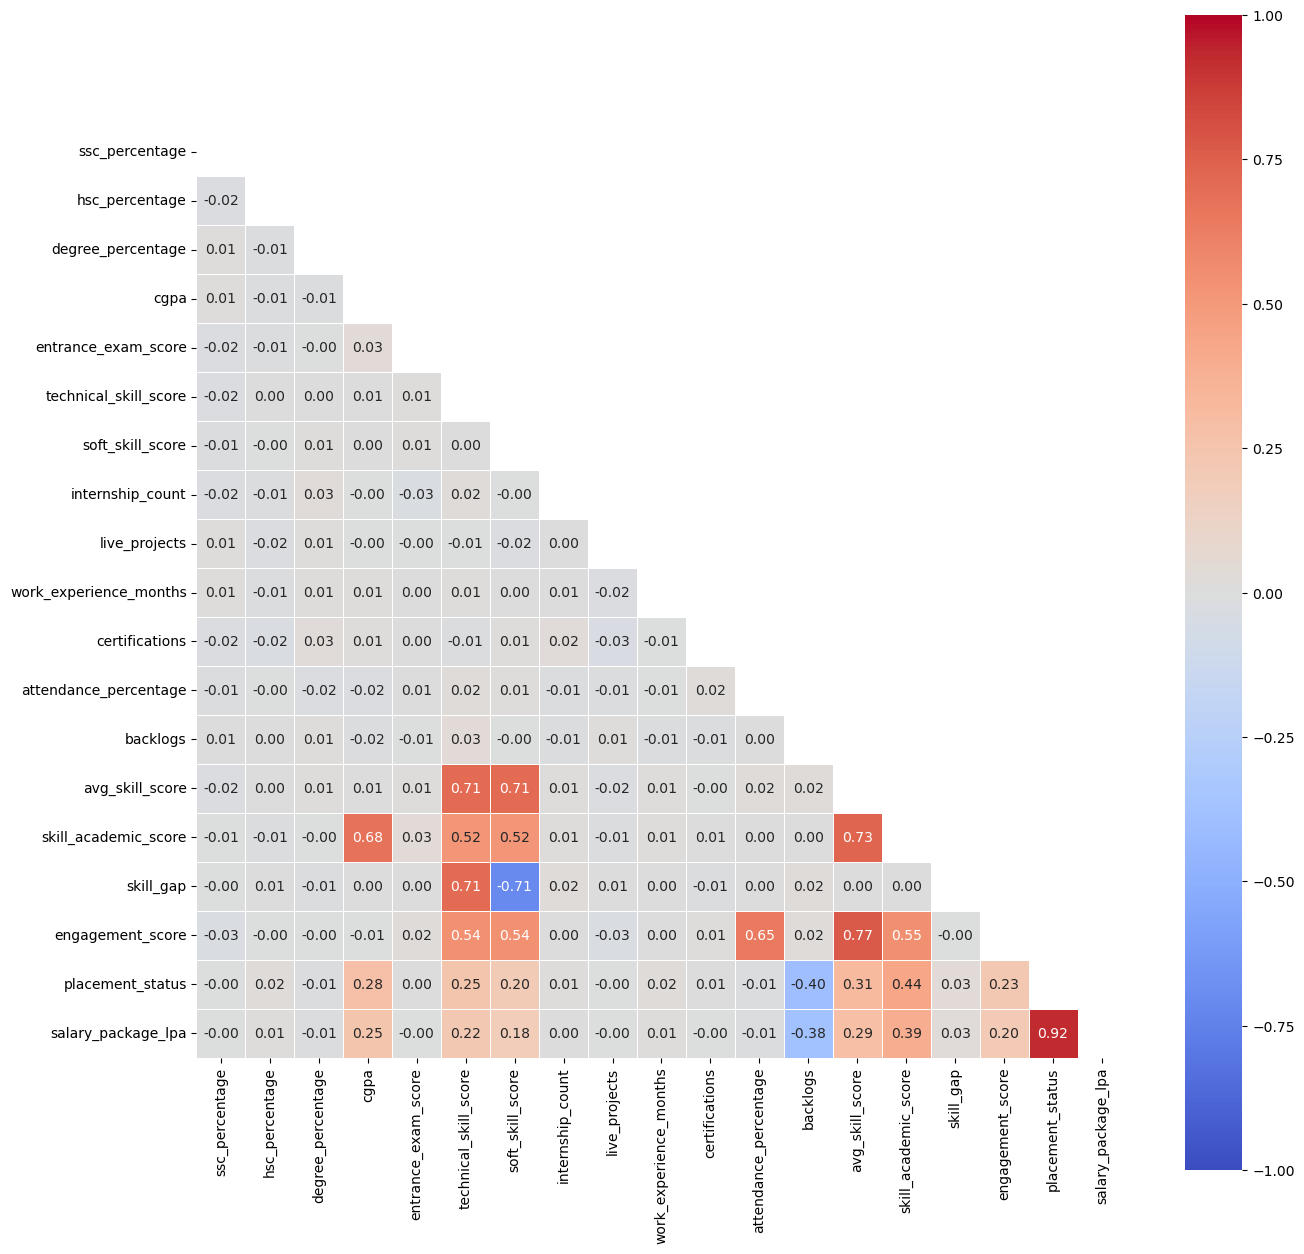

In [232]:
heatmap_col = list(num_col) + ['placement_status', 'salary_package_lpa']
corr = df[heatmap_col].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(15, 15))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)

Berdasarkan nilai correlation, didapatkan bahwa salary_package_lpa memiliki korelasi yang kuat dengan placement_status sebanyak 92%. Hal ini terjadi karena mereka yang mendapatkan penempatan kerja pasti mendapatkan salary package sehingga korelasinya sangat tinggi. Selain itu, terdapat 4 kolom yang memiliki korelasi kuat dengan placement_status, yaitu cgpa, technical_skill_score, soft_skill_score, dan backlogs. Keempat faktor tersebut menjadi penentu yang paling dilihat untuk menentukan penempatan kerja dan salarynya (berdasarkan nilai correlation).

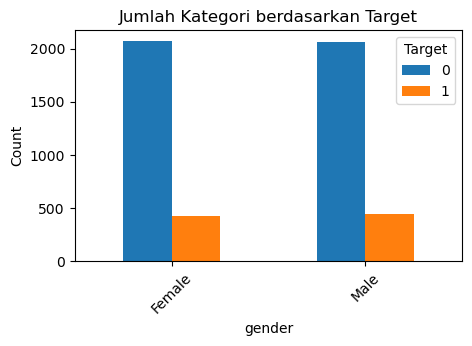

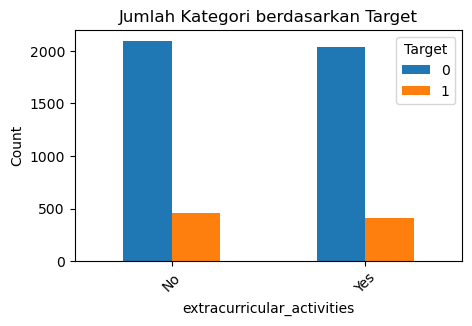

In [233]:
for i in cat_col:
    tabel_count = pd.crosstab(df[i], df['placement_status'])
    tabel_count.plot(kind='bar', figsize=(5, 3))
    plt.title('Jumlah Kategori berdasarkan Target')
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.legend(title='Target')
    plt.xticks(rotation=45)
    plt.show()

Dari data di atas, tidak ditemukan indikasi prediktor yang kuat antara target dengan gender dan aktivitas ekstrakurikuler. Maka dari itu, kedua kolom tersebut tidak akan dipakai karena tidak ada pembedaan arti.

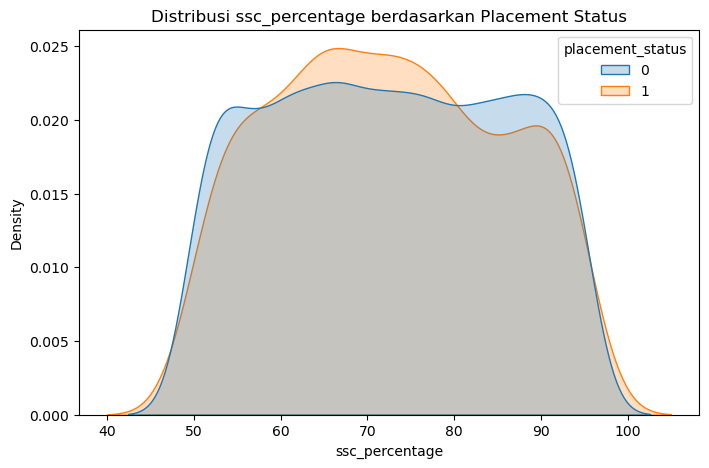

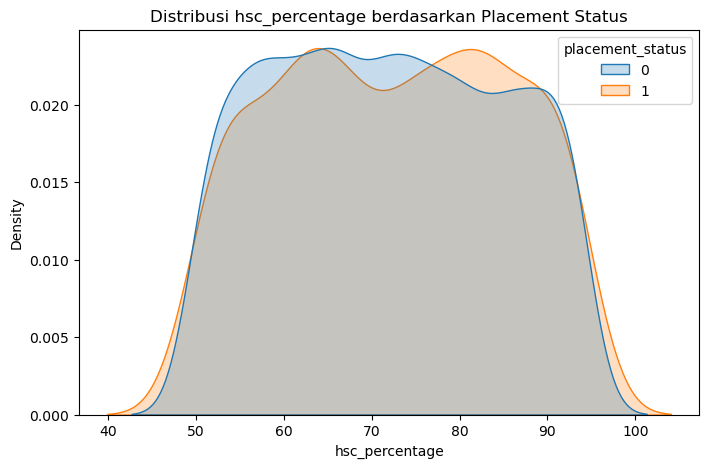

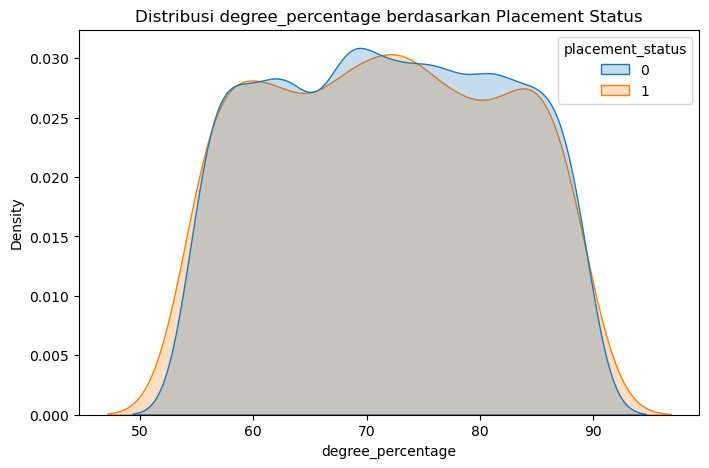

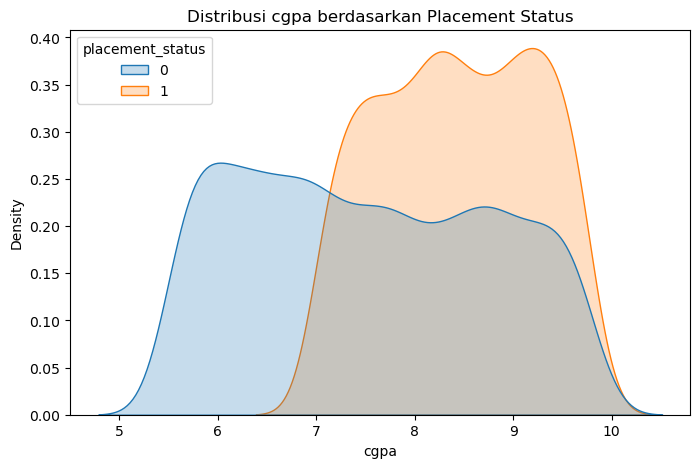

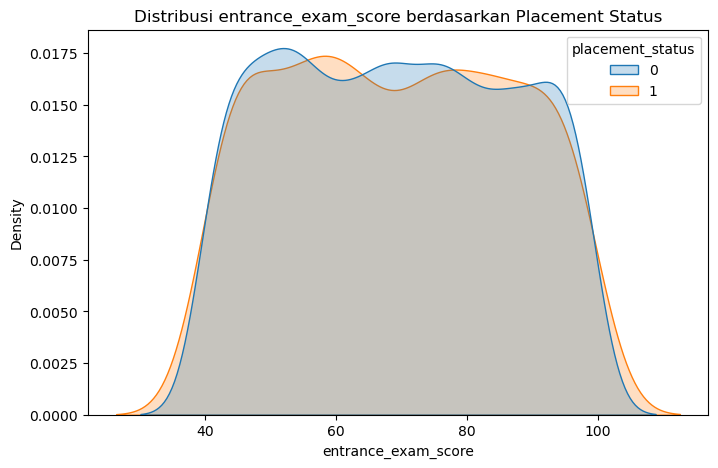

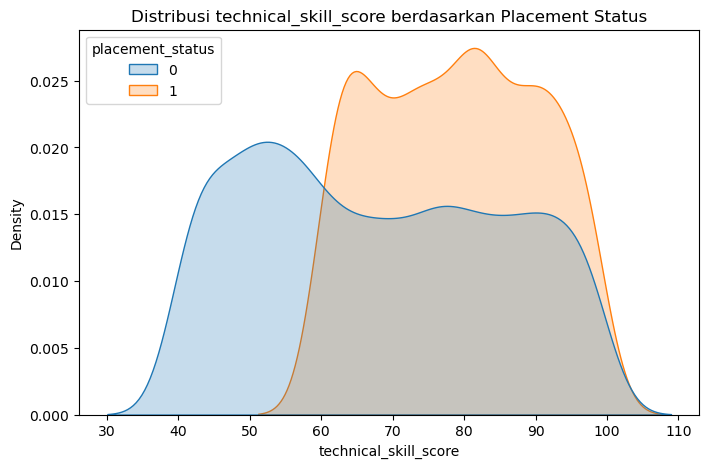

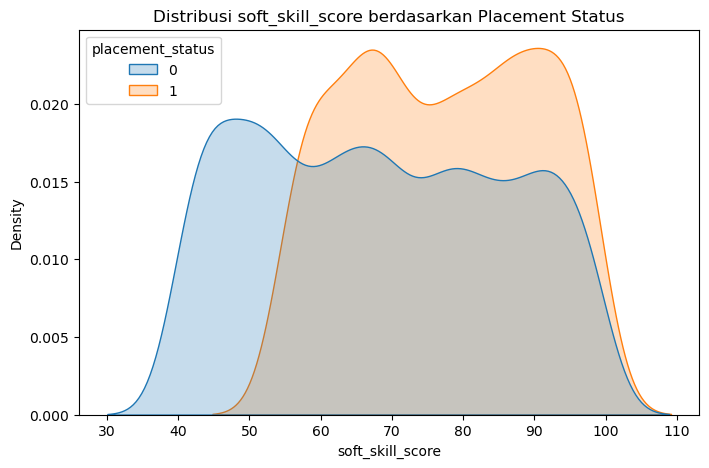

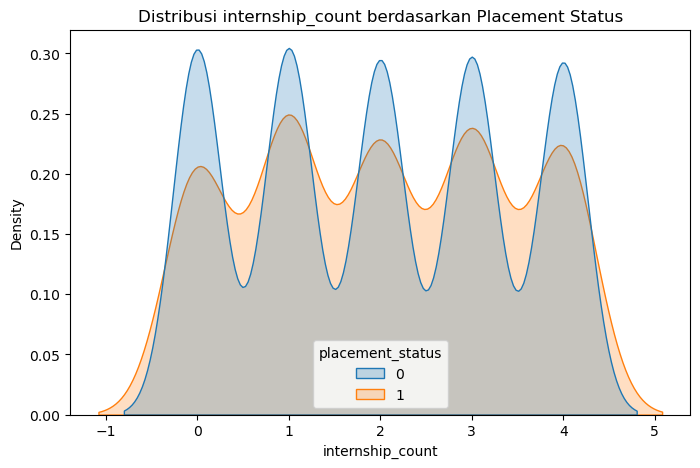

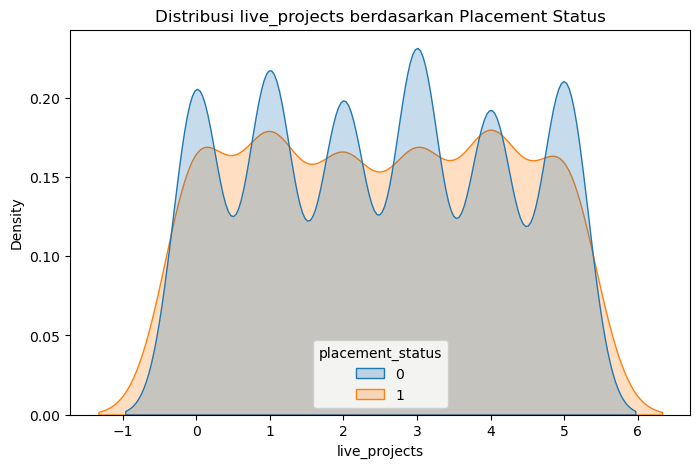

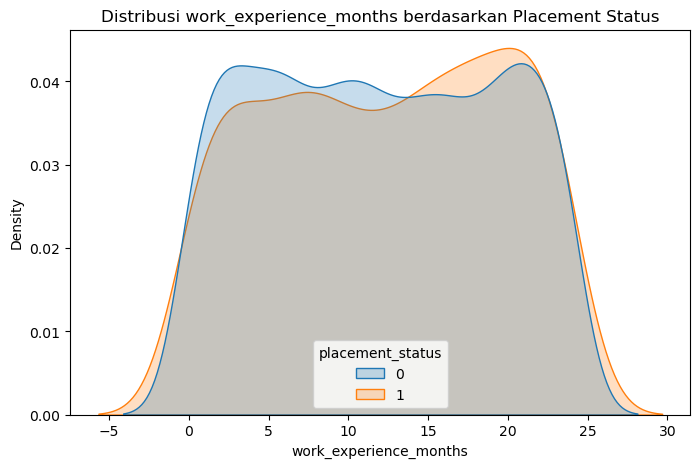

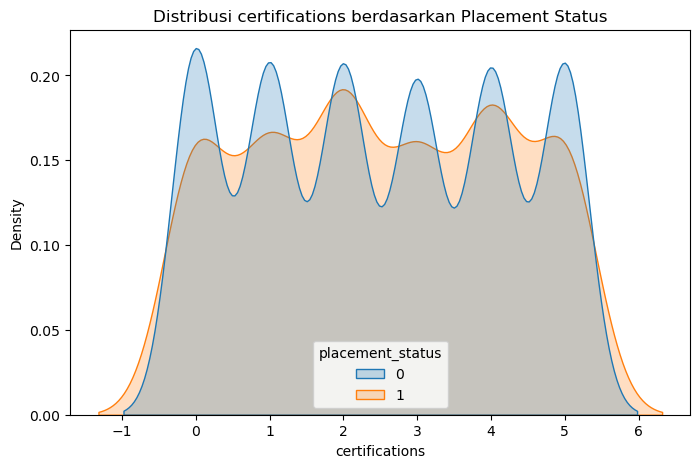

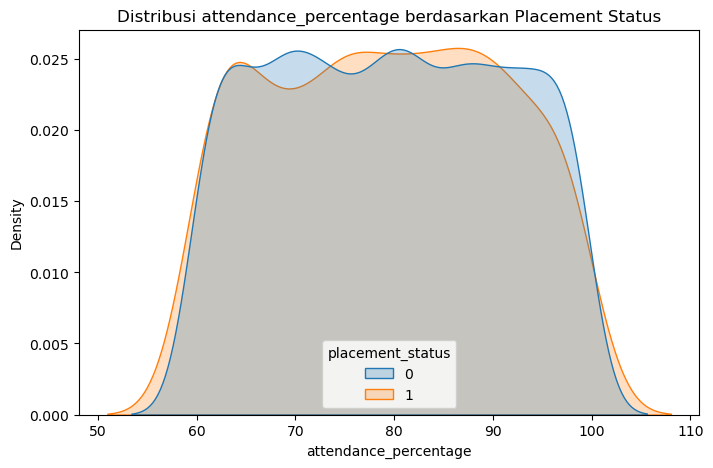

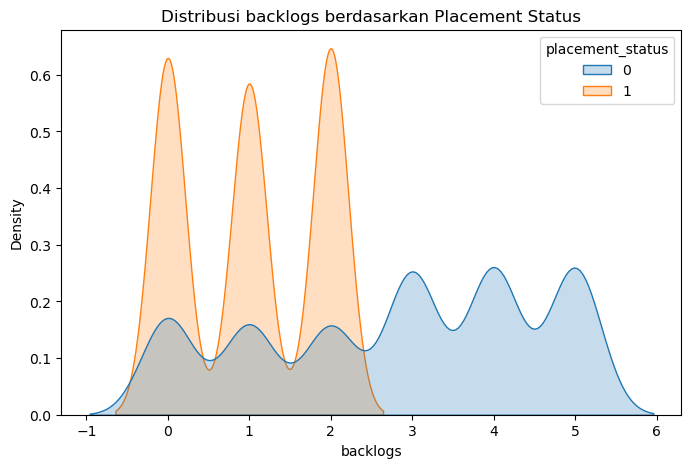

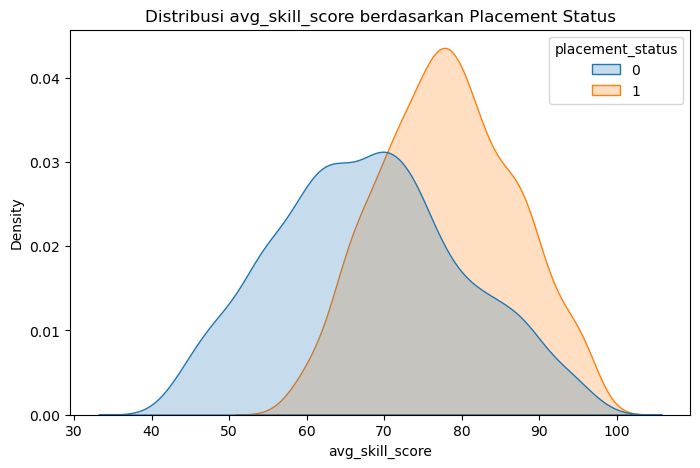

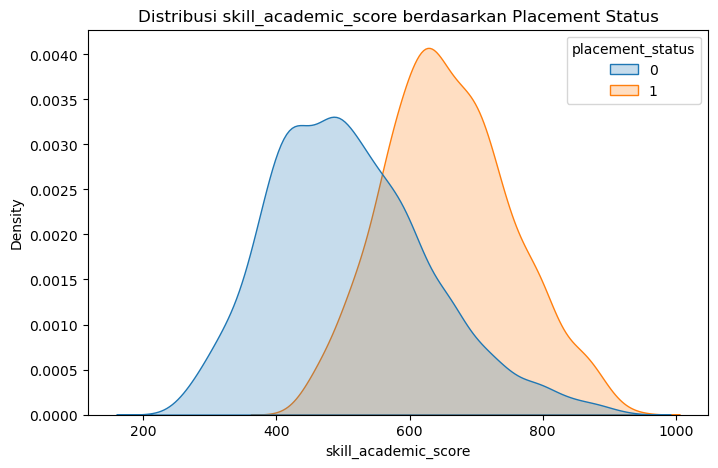

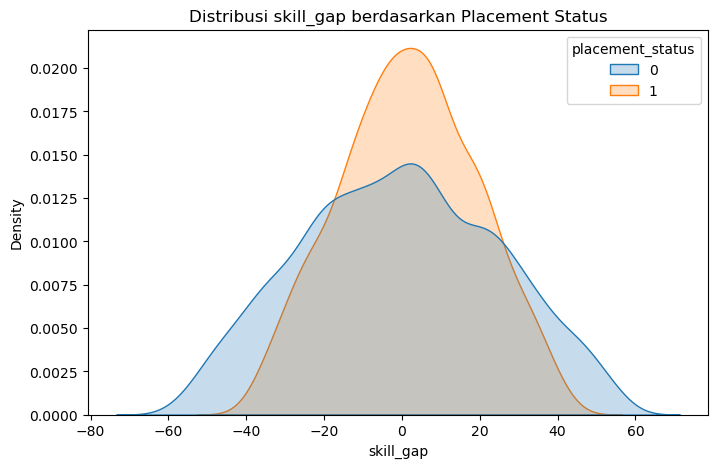

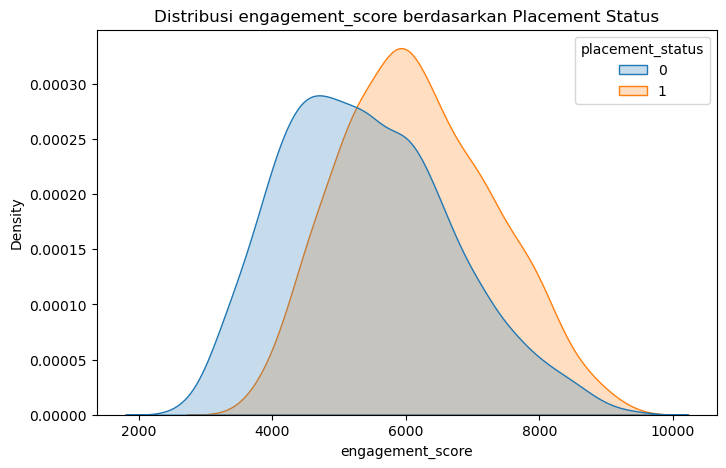

In [234]:
for col in num_col:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=col, hue='placement_status', fill=True, common_norm=False)
    plt.title(f'Distribusi {col} berdasarkan Placement Status')
    plt.show()

Berdasarkan hasil yang diperoleh, terdapat beberapa distribusi yang menunjukkan hasil yang baik (tidak tumpang tindih), yaitu:
- cgpa
- technical_skill_score
- soft_skill_score
- skill_academic_score
- backlogs
- avg_skill_score
- skill_gap
- engagement_score

Fitur-fitur tersebut dapat dipakai dalam pemodelan kali ini. Namun apabila dicocokan dengan nilai correlation, skill_gap tidak akan masuk ke dalam fitur karena tidak memiliki pengaruh apa-apa terhadap placement_status sehingga tidak akan dimasukkan ke dalam fitur. Kemudian, technical_skill_score dan soft_skill_score sudah termasuk ke dalam avg_skill_score sehingga kedua fitur tersebut juga tidak akan masuk ke dalam fitur untuk mencegah rendundant. Selain itu, untuk cgpa juga tidak akan dimasukkan ke dalam fitur ini karena sudah termasuk di dalam skill_academic_score. avg_skill_score dalam hal ini juga tidak dimasukkan ke dalam feature selection karena akan berpotensi rendundant dengan skill_academic_score. 

Maka dari itu, fitur fitur yang akan digunakan dalam pemodelan kali ini adalah:

- skill_academic_score
- backlogs
- engagement_score

=======================================================================================================================================================

**Kesimpulan Exploratory Data Analysis**

- Tidak ditemukan adanya NULL Values dan duplicated values, maka dari itu data cleaning tidak perlu dilakukan pada hal ini
- Berdasarkan nilai korelasi dan distribusi antara fitur-fitur dengan target, adanya fitur yang dapat berkontribusi untuk dilakukan pemodelan, yaitu:
    - skill_academic_score: skor gabungan antara akademik dengan skill yang dimiliki oleh seseorang
    - backlogs: jumlah mata kuliah yang tidak lulus
    - engagement_score: seberapa aktif seseorang dalam memanfaatkan skillnya berdasarkan skill yang dimiliki dan tingkat kehadirannya selama perkuliahan

    Ketiga faktor tersebut menjadi penentu utama terhadap keberhasilan penempatan kerja. Maka dari itu, ketiga fitur tersebut akan dipakai dalam pemodelan nantinya.
- Berdasarkan visualisasi kolom kategorikal, tidak ditemukan bahwa adanya indikasi pengaruh terhadap keberhasilan penempatan kerja sehingga tidak perlu dilakukannya feature engineering pada kolom kategorikal (gender dan extracurricular_activities)

In [262]:
feature_col = ['skill_academic_score', 'backlogs', 'engagement_score']

In [263]:
X = df[feature_col]
y = df['placement_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [244]:
X_train

,skill_academic_score,backlogs,engagement_score
483,499.260,2,6598.5
638,381.225,4,3145.0
936,526.500,2,6345.0
2932,505.750,5,8075.0
4154,637.275,4,4857.5
...,...,...,...
1417,614.880,2,4725.0
1958,418.390,2,4865.0
3175,422.475,4,4912.5
1878,429.640,5,4416.0


In [238]:
y_train

483     0
638     0
936     0
2932    0
4154    0
       ..
1417    0
1958    0
3175    0
1878    0
4602    0
Name: placement_status, Length: 4000, dtype: int64

## Classification Modelling - Logistic Regression

Accuracy: 0.898
Classification Report:               precision    recall  f1-score   support

           0       0.92      0.96      0.94       827
           1       0.76      0.61      0.67       173

    accuracy                           0.90      1000
   macro avg       0.84      0.78      0.81      1000
weighted avg       0.89      0.90      0.89      1000

Akurasi Train: 0.891
Akurasi Test: 0.898


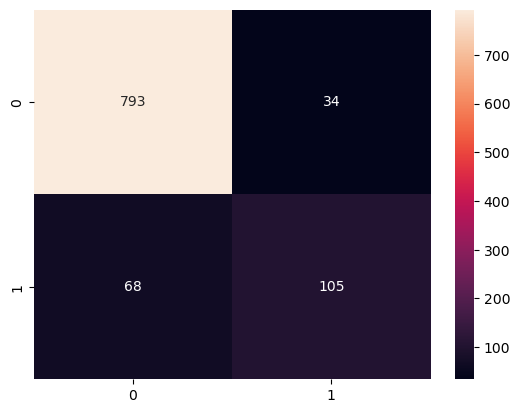

In [264]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report: {class_report}")

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

print(f"Akurasi Train: {model.score(X_train, y_train)}")
print(f"Akurasi Test: {model.score(X_test, y_test)}")

## Classification Modelling - Decision Tree Classifier

Accuracy: 0.88
Classification Report:               precision    recall  f1-score   support

           0       0.93      0.92      0.93       827
           1       0.65      0.68      0.66       173

    accuracy                           0.88      1000
   macro avg       0.79      0.80      0.79      1000
weighted avg       0.88      0.88      0.88      1000

Akurasi Train: 1.0
Akurasi Test: 0.88


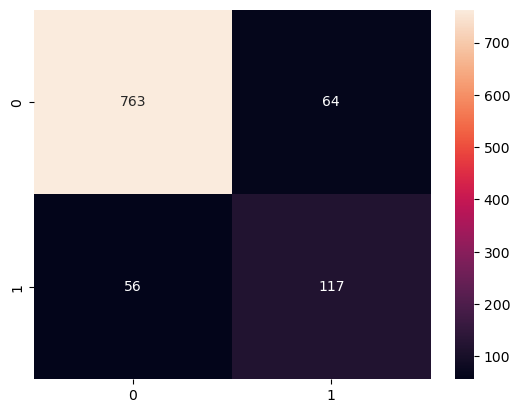

In [246]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report: {class_report}")


sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

print(f"Akurasi Train: {model.score(X_train, y_train)}")
print(f"Akurasi Test: {model.score(X_test, y_test)}")

## Classification Modelling - Random Forest Classifier

Accuracy: 0.937
Classification Report:               precision    recall  f1-score   support

           0       0.96      0.96      0.96       827
           1       0.82      0.82      0.82       173

    accuracy                           0.94      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.94      0.94      0.94      1000

Akurasi Train: 0.9275
Akurasi Test: 0.937


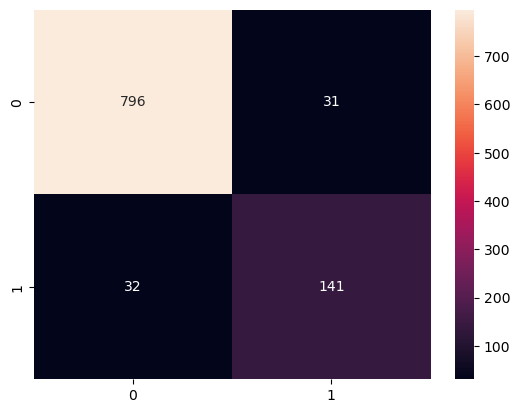

In [247]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Classification Report: {class_report}")

from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

print(f"Akurasi Train: {model.score(X_train, y_train)}")
print(f"Akurasi Test: {model.score(X_test, y_test)}")

Berdasarkan hasil modelling dengan menggunakan Logistic Regression, Decision Tree Classifier, dan Random Forest Classifier, didapatkan kesimpulan sebagai berikut:
- Modelling dengan Logistic Regression mendapatkan nilai akurasi yang baik dan tidak mengalami overfitting. Hal ini dapat dilihat pada pengetesan akurasi pada training dan testing yang tidak jauh berbeda yaitu sebesar 89.10% dan 89.80%. Selain itu, bila dilihat pada confussion matrix, angkanya cukup merata pada false positive, false negative, dan true negative dengan angka dominan pada true positive. Dengan hasil tersebut menunjukkan bahwa setidaknya masih terdapat tebakan yang salah dan menunjukkan bahwa model telah berusaha untuk belajar mengenali pola.
- Modelling dengan menggunakan decision tree juga menunjukkan adanya sedikit perbedaan dimana hasil akurasi training dan testingnya berbeda sejauh 12%. Hasil yang berbeda tersebut dapat menunjukkan adanya overfitting tipis pada model, karena trainingnya 100% dan testingnya 88% sehingga tidak disarankan untuk menjadi model utama
- Modelling dengan menggunakan random forest menunjukkan hasil yang baik, ditunjukkan dengan akurasi training sebesar 92.75% dan akurasi testing sebesar 93.7%. Angka tersebut lebih tinggi dibandingkan dengan logistic regression sehingga menunjukkan hasil yang lebih baik ketimbang logistic regression.

Dengan demikian, model classification yang digunakan untuk melakukan training dan testing pada dataset ini adalah Random Forest Classifier.

# Regression Modelling - Linear Regression

In [252]:
X = df[feature_col]
y_r = df['salary_package_lpa']
X_train, X_test, y_train, y_test = train_test_split(X, y_r, test_size=0.2, random_state=42, stratify=y)

In [253]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r_2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(r_2)
print(mae)
print(rmse)

0.300722487375472
2.2720800726615384
3.185838566804834


# Regression Modelling - Decision Tree Regression

In [251]:
param_grid_dt = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator= DecisionTreeRegressor(), 
    param_grid= param_grid_dt, 
    cv=5, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)
print("R2 Score Terbaik (CV):", grid_search.best_score_)

Parameter Terbaik: {'criterion': 'squared_error', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
R2 Score Terbaik (CV): 0.5025930114423846


In [260]:
model = DecisionTreeRegressor(criterion='squared_error', max_depth=5, min_samples_split=2, min_samples_leaf=4, max_features=None, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r_2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(r_2)
print(mae)
print(rmse)

0.5386882117229976
1.2407697824719315
2.587594745134199


# Regression Modelling - Random Forest Regression

In [255]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(), 
    param_grid=param_grid_rf, 
    cv=5, n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Parameter Terbaik:", grid_search.best_params_)
print("R2 Score Terbaik (CV):", grid_search.best_score_)

Parameter Terbaik: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
R2 Score Terbaik (CV): 0.4873095834318348


In [259]:
model = RandomForestRegressor(bootstrap= True, max_depth= 10, min_samples_leaf= 1, min_samples_split= 2, n_estimators= 200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r_2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(r_2)
print(mae)
print(rmse)

0.5274715167288218
1.2431084934610286
2.618864208645575


Berdasarkan modelling regression dengan menggunakan linear regression, decision tree regressor, dan random forest regressor, didapatkan hasil sebagai berikut:

Semua model menggunakan metrik yang sama, yaitu R², Mean Absolute Error (MAE), dan Root Mean Squared Error (RMSE). R² menjelaskan seberapa baik model menjelaskan variasi datanya, MAE merupakan rata-rata dari selisih mutlak antara nilai prediksi dan nilai asli, dan RMSE menjelaskan ukuran rata-rata seberapa jauh prediksi model "meleset" dari nilai aslinya. Artinya, model yang bagus adalah model dengan nilai R² yang tinggi dan nilai RMSE dan MAE yang rendah. Berdasarkan hal tersebut, ketiga model diatas dapat dianalisis dengan melihat skor dari masing-masing metriks.

Linear Regression:
- R² = 0.300722487375472
- MAE = 2.2720800726615384
- RMSE = 3.185838566804834

Decision Tree Regression:
- R² = 0.5386882117229976 **(Tertinggi)** --> Artinya model dapat menjelaskan sekitar 53.86% salary
- MAE = 1.2407697824719315 **(Terendah)** --> Rata-rata selisih mutlak antara nilai prediksi dan nilai asli yang dihasilkan model sebesar 1.24
- RMSE = 2.587594745134199 **(Terendah)** --> Rata-rata prediksi model "meleset" dari nilai aslinya

Random Forest Regression:
- R² = 0.5274715167288218
- MAE = 1.2431084934610286
- RMSE = 2.618864208645575

Dikarenakan hasil yang lebih dominan pada decision tree regression, maka dari itu untuk model regresi yang akan dipakai dalam model kali ini adalah decision tree regression